<img src="https://github.com/fynnbuhl/Machine-Vision-WS25-26/blob/main/mv_task_2/crisp_dm_yolo_model.jpg?raw=1" alt="crisp_dm_yolo_model" width="300">

### Projektaufgabe 2
#### Objekterkennung mittels YOLO

<b>Machine Vision (MV)</b><br>
<b>F09 / IPK / Cologne Laboratory for Artificial Intelligence and Smart Automation (CAISA)</b><br>
<b>V 2.0</b>

Aktuelles Semester: <font color="#FFFF00">WS25/26</font>

Gruppe: <font color="#FFFF00">3</font>

Name 1: <font color="#FFFF00">Jan Philipp Weiß</br></font>
Matrikel-Nr. 1: <font color="#FFFF00">11396262</br></font>
Mail 1: <font color="#FFFF00">jan_philipp.weiss@smail.th-koeln.de</font>

Name 2: <font color="#FFFF00">Kilian Feil</br></font>
Matrikel-Nr. 2: <font color="#FFFF00">11427791</br></font>
Mail 2: <font color="#FFFF00">kilian_niklas.feil@smail.th-koeln.de</font>

Name 3: <font color="#FFFF00">Fynn Buhl</br></font>
Matrikel-Nr. 3: <font color="#FFFF00">11396259</br></font>
Mail 3: <font color="#FFFF00">fynn.buhl@smail.th-koeln.de</font>

<b>Beachten Sie bitte bei der Lösung der Projektaufgabe folgende Hinweise:</b>

- Nutzen Sie für die vollständige Dokumentation diese Vorlage. Lesen Sie sich aufmerksam die Aufgaben durch und fügen Sie bitte die Lösung in die dafür vorgesehenen Zellen ein.

- Tragen Sie oben das aktuelle Semester, Ihre Gruppennummer sowie Ihre Namen, Matrikelnummern und Mail-Adressen ein.

- Arbeiten Sie sich bitte selbständig in die Programmierung mittels der Bibliotheken <i>scikit-learn</i>, <i>scikit-image</i>, <i>OpenCV</i>, <i>Keras/Tensorflow</i> und <i>YOLO</i> von <i>Ultralytics</i> ein.

- Diese Projektaufgabe wird gruppenbasiert durchgeführt und fließt zu 25 % in Ihre Endnote ein.

- Erledigen Sie nur die nachfolgend beschriebenen Aufgaben. Der Lösungsweg soll so knapp wie möglich gehalten werden und dennoch gut verständlich sein. Ansonsten folgt Punkteabzug!

- Sammeln Sie Ihre Fragen und stellen Sie diese während der angebotenen Beratungsgespräche. Das Forum kann ebenfalls genutzt werden, beachten Sie jedoch, dass die Beantwortung erheblich länger dauern wird, da dieses nur an einem Tag in der Woche von uns eingesehen wird.

- Es wird großer Wert auf einen sauberen und gut dokumentierten Programmierstil gelegt. Achten Sie dementsprechend, dass zusammenhängende, größere Verfahrensabschnitte näher erläutert werden. Bereiten Sie das Skript so vor, dass ein Machine-Learning-Neuling das Ziel und die einzelnen Schritte nachvollziehen kann.

- Laden Sie bitte fristgemäß (s. Organisationsfolie) Ihre Abgabe (dieses Jupyter-Notebooks-Skript im <u>vollständig ausgeführten Zustand sowie mit Kommentaren und ggf. Antworten zu den jeweiligen Fragen</u>) im jeweiligen Gruppenordner auf ILU hoch. Pro Gruppe (und Projektaufgabe) nur ein Upload!

In [ ]:
# Standardbibliotheken

# Drittanbieterbibliotheken


In [1]:
# Daten-Archiv vor Verabeitung in Google Colab-Laufzeit entpacken
!unzip -q /content/PREPROC.zip

#### Aufgabe 1

Betrachten Sie den bearbeiteten Bilddatensatz (d.h. denjenigen, den Sie beim Abschluss der ersten Projektaufgabe gespeichert haben) und die zugehörigen Label-Dateien. Schreiben Sie die folgende YAML-Datei und speichern Sie diese als <i>yolo_v11.yaml</i> im Arbeitsordner:

<i>train: […]/training/images</i><br>
<i>val:   […]/validation/images</i><br>
<i>test:   […]/test/images</i><br>
<i>nc: 2</i><br>
<i>names: [‘OK‘, ‘NOK‘]</i>

Prüfen Sie das Format der Label-Dateien und adaptieren Sie dieses in das YOLO format.

In [2]:
import os

# --- Konfiguration der Zielpfade ---
# Wir definieren hier die Pfade, damit sie für die YAML-Datei verfügbar sind,
# bevor die Daten tatsächlich dorthin kopiert werden.
output_base_dir = "/content/dataset_split"

# Definition der Bild-Verzeichnisse für Training, Validierung und Test
train_img_dir = os.path.join(output_base_dir, "training", "images")
val_img_dir = os.path.join(output_base_dir, "validation", "images")
test_img_dir = os.path.join(output_base_dir, "test", "images")

# Sicherstellen, dass absolute Pfade verwendet werden
absolute_train_img_dir = os.path.abspath(train_img_dir)
absolute_val_img_dir = os.path.abspath(val_img_dir)
absolute_test_img_dir = os.path.abspath(test_img_dir)

# --- Erstellen der YOLO-Konfigurationsdatei ---
yaml_filename = "yolo_v11.yaml"

# Inhalt der YAML-Datei als String formatieren
yaml_content = f"""
train: {absolute_train_img_dir}
val:   {absolute_val_img_dir}
test:  {absolute_test_img_dir}
nc: 2
names: ['OK', 'NOK']
"""

# YAML-Datei erstellen und speichern
with open(yaml_filename, 'w') as f:
    f.write(yaml_content)

print(f"Die Datei '{yaml_filename}' wurde erfolgreich erstellt.")
print(f"Konfigurierter Trainingspfad:   {absolute_train_img_dir}")
print(f"Konfigurierter Validierungspfad: {absolute_val_img_dir}")
print(f"Konfigurierter Testpfad:        {absolute_test_img_dir}")
print("-" * 30)
print("Inhalt der YAML-Datei:")
print(yaml_content)

Die Datei 'yolo_v11.yaml' wurde erfolgreich erstellt.
Konfigurierter Trainingspfad:   /content/dataset_split/training/images
Konfigurierter Validierungspfad: /content/dataset_split/validation/images
Konfigurierter Testpfad:        /content/dataset_split/test/images
------------------------------
Inhalt der YAML-Datei:

train: /content/dataset_split/training/images
val:   /content/dataset_split/validation/images
test:  /content/dataset_split/test/images
nc: 2
names: ['OK', 'NOK']



#### Aufgabe 2

Splitten Sie den in der Projektaufgabe 1 verarbeiteten Datensatz in Trainings- , Validierungs- und Testdaten mit folgender Gewichtung auf: 80 %, 10 %, 10 %.

In [3]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split
from PIL import Image  # Benötigt für Bilddimensionen (pip install Pillow)

# --- Pfad-Konfigurationen ---
data_dir = "/content/PREPROC"
ok_dir = os.path.join(data_dir, "OK_preproc")
nok_dir = os.path.join(data_dir, "NOK_preproc")

train_img_dir = os.path.join(output_base_dir, "training", "images")
train_lbl_dir = os.path.join(output_base_dir, "training", "labels")
val_img_dir = os.path.join(output_base_dir, "validation", "images")
val_lbl_dir = os.path.join(output_base_dir, "validation", "labels")
test_img_dir = os.path.join(output_base_dir, "test", "images")
test_lbl_dir = os.path.join(output_base_dir, "test", "labels")

# --- Vorbereitung ---

# Erstelle alle benötigten Verzeichnisse
dirs_to_create = [
    train_img_dir, train_lbl_dir,
    val_img_dir, val_lbl_dir,
    test_img_dir, test_lbl_dir
]

for path in dirs_to_create:
    os.makedirs(path, exist_ok=True)


def get_image_label_pairs(directory):
    """
    Sammelt Paare von Bild- und zugehörigen Label-Dateien aus einem Verzeichnis.
    """
    # Filtern nach .jpg und .txt
    image_files = sorted([f for f in os.listdir(directory) if f.endswith(".jpg")])
    label_files = set(f for f in os.listdir(directory) if f.endswith(".txt"))

    pairs = []
    for img_file in image_files:
        base_name = os.path.splitext(img_file)[0]
        label_file = base_name + ".txt"
        if label_file in label_files:
            pairs.append((
                os.path.join(directory, img_file),
                os.path.join(directory, label_file)
            ))
    return pairs


def convert_lable_to_yolo(line, img_width, img_height):
    """
    Wandelt eine Zeile des alten Formats in das YOLO-Format um.
    Input Format: Filename, Class, UL_X, UL_Y, UR_X, UR_Y, LR_X, LR_Y, LL_X, LL_Y
    Output Format: class_id center_x center_y width height (normalisiert 0-1)
    """
    parts = line.strip().split(',')

    # Überspringe Header-Zeilen oder leere Zeilen
    if not parts or not parts[1].strip().isdigit():
        return None

    # Extrahiere Klassennummer (Index 1)
    class_id = int(parts[1].strip())

    # Extrahiere Koordinaten (ab Index 2)
    # Format: UL(x,y), UR(x,y), LR(x,y), LL(x,y)
    coords = [float(x) for x in parts[2:]]

    # Wir sammeln alle X- und Y-Werte, um Min/Max zu finden (Bounding Box)
    # Skript nimmt sicherheitshalber min() und max() aller X- und Y-Werte. Das garantiert, dass die Box korrekt ist, selbst wenn die Reihenfolge im Input mal leicht abweicht oder das Rechteck nicht perfekt rotiert ist (YOLO unterstützt standardmäßig nur achsenparallele Boxen).
    x_values = coords[0::2]  # Jedes zweite Element startend bei 0
    y_values = coords[1::2]  # Jedes zweite Element startend bei 1

    min_x = min(x_values)
    max_x = max(x_values)
    min_y = min(y_values)
    max_y = max(y_values)

    # Berechne Box-Dimensionen
    box_width = max_x - min_x
    box_height = max_y - min_y
    center_x = min_x + (box_width / 2)
    center_y = min_y + (box_height / 2)

    # Normalisierung (Werte durch Bildgröße teilen)
    norm_center_x = center_x / img_width
    norm_center_y = center_y / img_height
    norm_width = box_width / img_width
    norm_height = box_height / img_height

    # Begrenzung auf [0, 1] zur Sicherheit (clipping)
    norm_center_x = max(0.0, min(1.0, norm_center_x))
    norm_center_y = max(0.0, min(1.0, norm_center_y))
    norm_width = max(0.0, min(1.0, norm_width))
    norm_height = max(0.0, min(1.0, norm_height))

    # YOLO Format String (6 Nachkommastellen reichen meistens)
    return f"{class_id} {norm_center_x:.6f} {norm_center_y:.6f} {norm_width:.6f} {norm_height:.6f}"


def process_and_copy_files(pairs, img_dest_dir, lbl_dest_dir):
    """
    Kopiert Bilder und konvertiert Label-Dateien ins YOLO-Format.
    """
    for img_src, lbl_src in pairs:
        # 1. Bild kopieren
        shutil.copy(img_src, img_dest_dir)

        # 2. Bild öffnen, um Dimensionen zu erhalten (nötig für Normalisierung)
        with Image.open(img_src) as img:
            img_width, img_height = img.size


        # 3. Label-Datei lesen, konvertieren und schreiben
        dest_lbl_path = os.path.join(lbl_dest_dir, os.path.basename(lbl_src))

        with open(lbl_src, "r") as f_in, open(dest_lbl_path, "w") as f_out:
            lines = f_in.readlines()
            for line in lines:
                # Header 'Image', 'Object_Class'... überspringen
                if "Object_Class" in line or "upperLeftX" in line:
                    continue

                yolo_line = convert_lable_to_yolo(line, img_width, img_height)
                if yolo_line:
                    f_out.write(yolo_line + "\n")


# --- Hauptablauf ---

# Sammle alle Bild-Label-Paare
print("Sammle Daten...")
all_ok_pairs = get_image_label_pairs(ok_dir)
all_nok_pairs = get_image_label_pairs(nok_dir)


all_pairs = all_ok_pairs + all_nok_pairs


# Mischen der Daten
random.seed(42)
random.shuffle(all_pairs)

# --- Aufteilung des Datensatzes ---
train_pairs, val_test_pairs = train_test_split(
    all_pairs, test_size=0.2, random_state=42
)

val_pairs, test_pairs = train_test_split(
    val_test_pairs, test_size=0.5, random_state=42
)

print(f"Gesamtzahl der Paare: {len(all_pairs)}")
print(f"Trainingspaare:      {len(train_pairs)}")
print(f"Validierungspaare:   {len(val_pairs)}")
print(f"Testpaare:           {len(test_pairs)}")

# Verarbeitung und Konvertierung
print("\nVerarbeite Trainingsdateien (Kopieren + Konvertieren)...")
process_and_copy_files(train_pairs, train_img_dir, train_lbl_dir)

print("Verarbeite Validierungsdateien...")
process_and_copy_files(val_pairs, val_img_dir, val_lbl_dir)

print("Verarbeite Testdateien...")
process_and_copy_files(test_pairs, test_img_dir, test_lbl_dir)

print("\nDatensatzaufteilung und YOLO-Konvertierung abgeschlossen!")
print(f"Ausgabeordner: {output_base_dir}")

Sammle Daten...
Gesamtzahl der Paare: 939
Trainingspaare:      751
Validierungspaare:   94
Testpaare:           94

Verarbeite Trainingsdateien (Kopieren + Konvertieren)...
Verarbeite Validierungsdateien...
Verarbeite Testdateien...

Datensatzaufteilung und YOLO-Konvertierung abgeschlossen!
Ausgabeordner: /content/dataset_split


#### Aufgabe 3

Erstellen Sie eine Instanz des <i>YOLO-Modells 11n</i> und trainieren Sie das YOLO-Modell. Nutzen Sie hierfür die zuvor definierte <i>YAML</i>-Datei. Trainieren Sie über drei Epochen. Schauen Sie sich die Ergebnisse im automatisch angelegten Ordern <i>runs</i> an.


In [4]:
# Installation der Ultralytics-Bibliothek (nur einmalig nötig pro Session)
# Das '!' sagt Colab, dass dies ein Befehl für die Konsole ist, nicht Python.
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.0 MB/s eta 0:00:00


In [5]:
from ultralytics import YOLO

# Pfad zur YAML-Konfigurationsdatei
# Die Datei wurde in einer vorherigen Zelle als 'yolo_11.yaml' erstellt.
# Wir verwenden direkt den Dateinamen, da sie im aktuellen Arbeitsverzeichnis liegt.

# YOLOv11n Modell instanziieren
# 'n' steht hier für die Nano-Version des Modells, die oft eine gute Ausgangsbasis ist.
# Bei Bedarf kann dies später auf größere Modelle wie 'yolo11s.pt', 'yolo11m.pt' usw. geändert werden.
model = YOLO('yolo11n.pt')  # Lade ein vortrainiertes YOLO11n-Modell

# Modell trainieren
# 'data' verweist auf die YAML-Datei, die die Pfade zu den Trainings- und Validierungsdaten enthält.
# 'epochs' definiert die Anzahl der Trainingsdurchläufe über den gesamten Datensatz.
# Das Argument 'imgsz' (Bildgröße) kann hier optional auf eine Standardgröße wie 640 gesetzt werden,
# da YOLOv11-Modelle standardmäßig oft mit 640x640 Bildern trainiert werden.
# Wenn nicht explizit angegeben, verwendet Ultralytics eine Standardgröße, meist 640.

#YOLO nimmt Ihr Bild (egal ob 4000x3000 oder 100x100 Pixel) und passt es automatisch in ein 640x640 Quadrat ein.
    #Verzerrung: Das Bild wird dabei nicht verzerrt.
    #Padding: Stattdessen fügt YOLO graue Ränder (Padding) hinzu, um das Quadrat aufzufüllen. Das nennt man "Letterboxing" (ähnlich wie bei einem Kinofilm auf einem alten Fernseher).
results = model.train(data=yaml_filename, epochs=3, imgsz=640)

print("\nModelltraining abgeschlossen. Die Ergebnisse sind im 'runs'-Ordner zu finden.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_v11.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_widt

Ergebnisanalyse des Ordner "runs"

Analysiere Ergebnisse aus: runs/detect/train

--- Trainingsverlauf (Loss & Metriken) ---


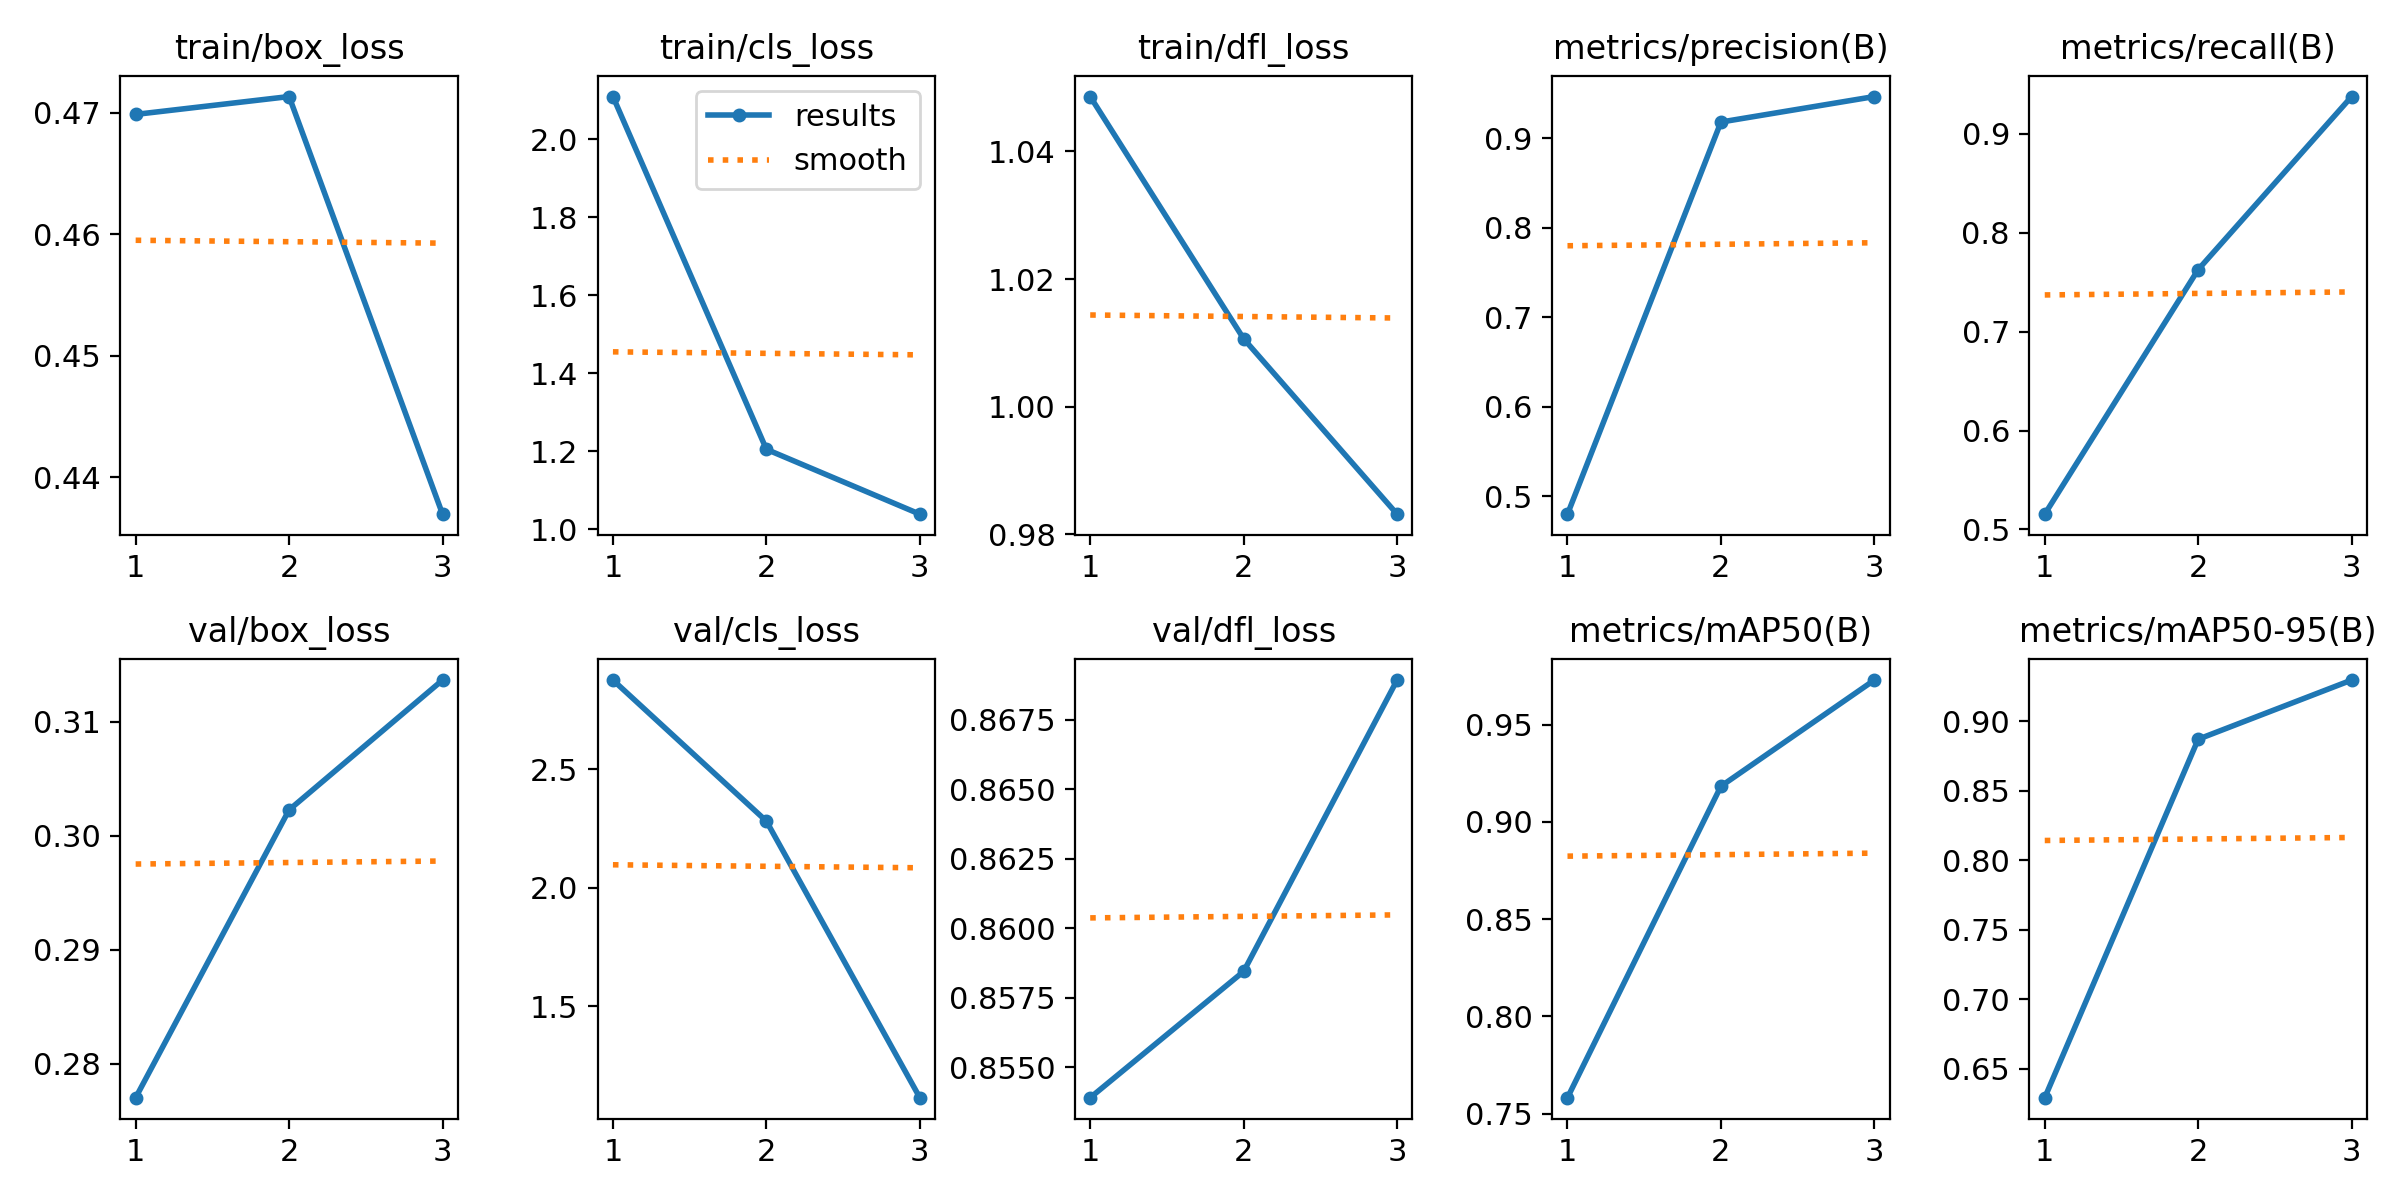


--- Beispiel-Vorhersagen auf Validierungsdaten ---


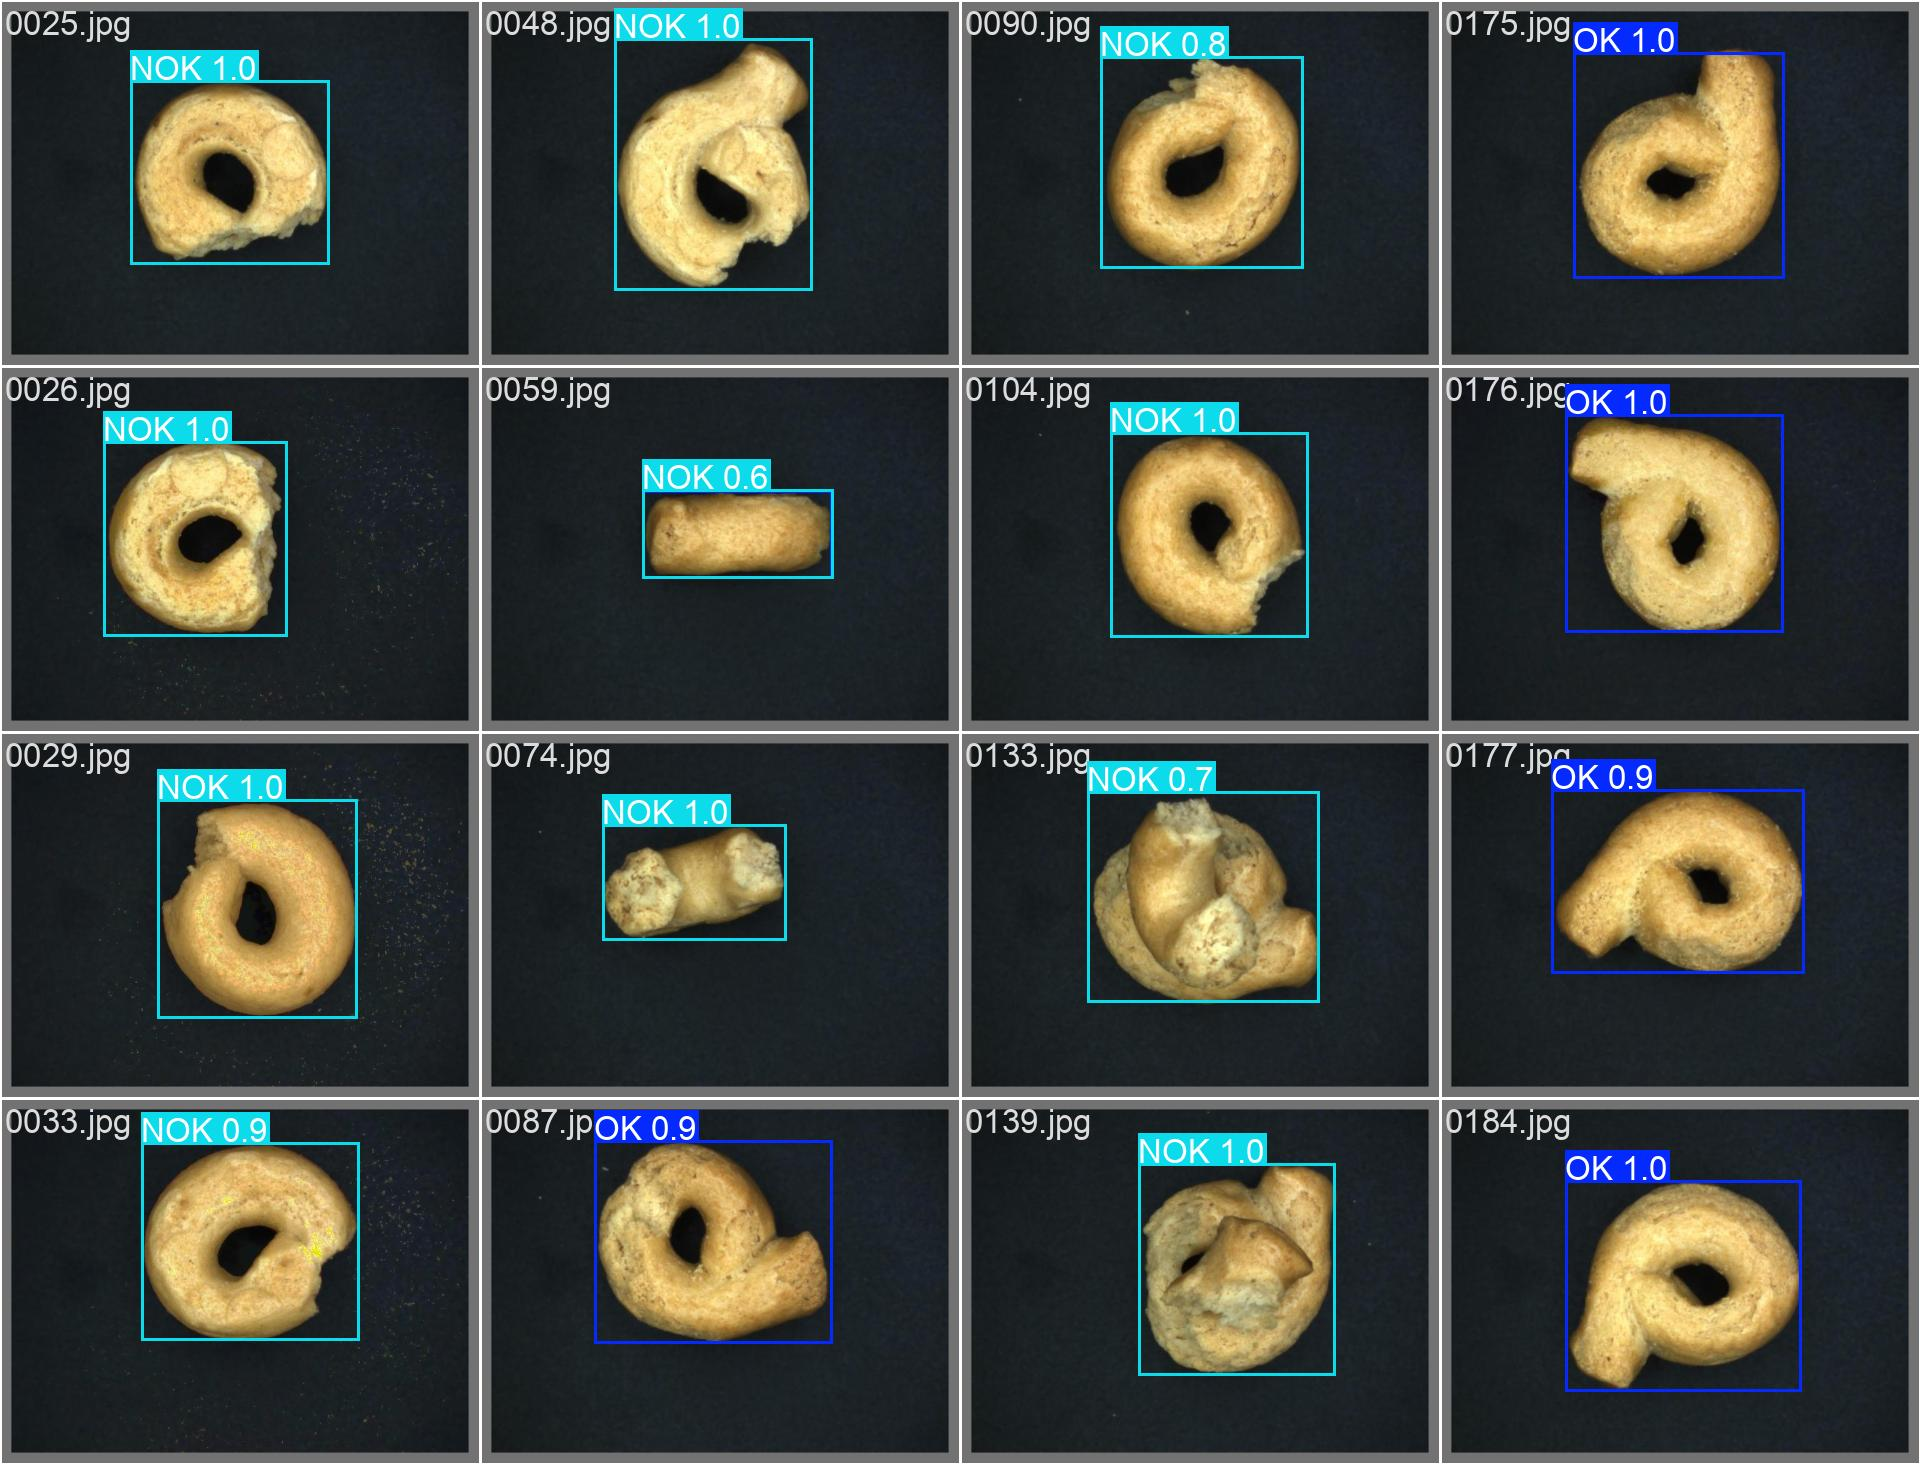

In [6]:
import os
import glob
from IPython.display import Image, display

# 1. Den neuesten Trainings-Ordner finden
# YOLO legt Ordner wie 'runs/detect/train', 'runs/detect/train2' an.
# Wir wollen den aktuellsten, um die Ergebnisse des letzten Trainings zu sehen.
base_path = 'runs/detect'
# Suche alle Ordner, die mit 'train' beginnen
list_of_train_runs = glob.glob(os.path.join(base_path, 'train*'))

if list_of_train_runs:
    # Den neuesten Ordner basierend auf der Erstellungszeit ermitteln
    latest_run = max(list_of_train_runs, key=os.path.getctime)
    print(f"Analysiere Ergebnisse aus: {latest_run}")

    # 2. Die Trainings-Metriken anzeigen (results.png)
    # Diese Grafik zeigt den Verlauf von Loss und Genauigkeit über die Epochen.
    results_path = os.path.join(latest_run, 'results.png')
    if os.path.exists(results_path):
        print("\n--- Trainingsverlauf (Loss & Metriken) ---")
        display(Image(filename=results_path, width=800))
    else:
        print("Keine 'results.png' gefunden. Training war evtl. zu kurz oder fehlerhaft.")

    # 3. Validierungs-Vorhersagen anzeigen (val_batch*_pred.jpg)
    # Das zeigt, wie das Modell auf Bilder reagiert, die es beim Training nicht zum Lernen genutzt hat.
    # Wir suchen das erste Batch-Bild mit Vorhersagen.
    val_pred_path = os.path.join(latest_run, 'val_batch0_pred.jpg')
    if os.path.exists(val_pred_path):
        print("\n--- Beispiel-Vorhersagen auf Validierungsdaten ---")
        display(Image(filename=val_pred_path, width=800))
    else:
        print("Keine Vorhersage-Bilder gefunden.")

else:
    print("Keine Trainings-Ordner in 'runs/detect/' gefunden.")

#### Aufgabe 4

Führen Sie eine Objekterkennung mittels des trainierten YOLO-Modells unter Verwendung des Testdatensatzes durch. Setzen Sie das Argument <i>save</i> auf <i>True</i>.

In [17]:
# Pfad zum Testdatensatz definieren
# HINWEIS: Passen Sie diesen Pfad an den Ort an, wo Ihre Testbilder liegen.
# Oft ist dies ein Unterordner wie 'datasets/test/images' oder ähnlich.
test_images_path = "/content/dataset_split/test/images"

# Objekterkennung (Inferenz) auf dem Testdatensatz durchführen
# Wir verwenden das bereits trainierte Modell aus Aufgabe 3.
#
# Argumente:
# - source: Pfad zu den Bildern (Einzelbild, Ordner oder Video).
# - save=True: Speichert die Bilder mit den eingezeichneten Vorhersagen (Bounding Boxes).
# - imgsz=640: Setzt die Bildgröße passend zum Training.
# - conf=0.25: (Optional) Schwellenwert für die Konfidenz. Nur Vorhersagen
#              über diesem Wert werden angezeigt (Standard ist oft 0.25).
detection_results = model.predict(
    source=test_images_path,
    save=True,
    imgsz=640,
    conf=0.25,
    # Vorher waren zwie Klassen auf einem Bild detectet
    # Jetzt ist nms aktiviert welches das unterdrückt
    agnostic_nms=True
)

print(f"\nObjekterkennung abgeschlossen.")
print(f"Die Bilder mit den Vorhersagen wurden im 'runs/detect/predict'-Ordner gespeichert.")


image 1/94 /content/dataset_split/test/images/0018.jpg: 480x640 1 NOK, 118.1ms
image 2/94 /content/dataset_split/test/images/0021.jpg: 480x640 1 NOK, 115.5ms
image 3/94 /content/dataset_split/test/images/0034.jpg: 480x640 1 NOK, 116.8ms
image 4/94 /content/dataset_split/test/images/0044.jpg: 480x640 1 NOK, 115.9ms
image 5/94 /content/dataset_split/test/images/0050.jpg: 480x640 1 NOK, 115.4ms
image 6/94 /content/dataset_split/test/images/0060.jpg: 480x640 1 NOK, 118.2ms
image 7/94 /content/dataset_split/test/images/0062.jpg: 480x640 1 NOK, 111.8ms
image 8/94 /content/dataset_split/test/images/0072.jpg: 480x640 1 NOK, 121.8ms
image 9/94 /content/dataset_split/test/images/0073.jpg: 480x640 (no detections), 116.8ms
image 10/94 /content/dataset_split/test/images/0075.jpg: 480x640 1 NOK, 116.0ms
image 11/94 /content/dataset_split/test/images/0091.jpg: 480x640 1 NOK, 114.3ms
image 12/94 /content/dataset_split/test/images/0111.jpg: 480x640 1 NOK, 110.2ms
image 13/94 /content/dataset_split/tes

#### Aufgabe 5

Bewerten Sie die Leistung des Modells nur anhand der standardmäßig angelegten Leistungsmetriken <i>Precision</i>, <i>Recall</i>, <i>F1-score</i> und <i>Mean Average Precision</i> (<i>mAP</i>). Geben Sie diese Größen mithilfe des Befehls <i>print()</i> aus. Zeigen Sie außerdem den Verlauf der Kostenfunktionen (Loss functions) für das Training und die Validierung als Diagramme an.

Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (AMD EPYC 7B12)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 875.9±260.0 MB/s, size: 16.1 KB)
val: Scanning /content/dataset_split/test/labels.cache... 94 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 94/94 135.9Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.4s/it 14.3s
                   all         94         94      0.937      0.985      0.978      0.923
                    OK         49         49      0.975       0.98       0.99      0.975
                   NOK         45         45      0.899      0.991      0.966      0.872
Speed: 1.6ms preprocess, 127.9ms inference, 0.0ms loss, 17.6ms postprocess per image
Results saved to /content/runs/detect/test_run4

ERGEBNISSE AUF TESTDATEN
Precision:          0.9373
Recall:             0.9852
F1-Score:           0.9606
mAP (IoU=0.5):      0.9783
mAP (IoU=0.5:0.95): 0.9232



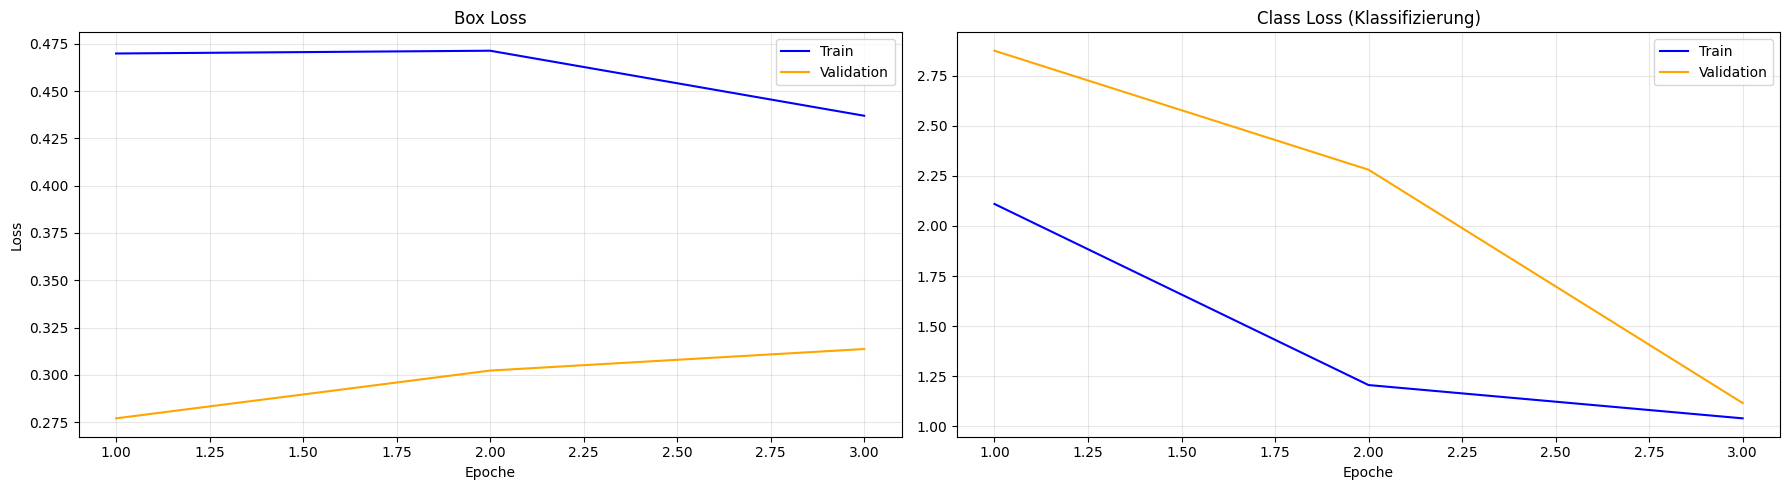

In [19]:
# Wie ist das mit Generalisierbarkeit?!
# Wie geht er mit den Doppelten Klassifizierung um (im Bezug auf Metrics)
# Kommentar zu no detections nicht vergessen

# Annahme: Die Variable 'model' ist bereits geladen
# Wir führen die Validierung explizit auf dem 'test'-Split durch
results = model.val(split='test', name='test_run')

# Ergebnisse extrahieren
# .box enthält die Metriken für Object Detection
precision = results.box.mp   # Mean Precision (Durchschnitt über alle Klassen)
recall    = results.box.mr   # Mean Recall
map50     = results.box.map50  # mAP bei IoU Threshold 0.5
map5095   = results.box.map    # mAP bei IoU 0.5 bis 0.95

# F1-Score Berechnung (Harmonisches Mittel aus Precision und Recall)
# Dies gibt einen guten Gesamteindruck der Balance zwischen P und R
if (precision + recall) > 0:
    f1 = 2 * (precision * recall) / (precision + recall)
else:
    f1 = 0.0

# Ausgabe mit print()
print("\n" + "="*40)
print("ERGEBNISSE AUF TESTDATEN")
print("="*40)
print(f"Precision:          {precision:.4f}")
print(f"Recall:             {recall:.4f}")
print(f"F1-Score:           {f1:.4f}")
print(f"mAP (IoU=0.5):      {map50:.4f}")
print(f"mAP (IoU=0.5:0.95): {map5095:.4f}")
print("="*40 + "\n")

import pandas as pd
import matplotlib.pyplot as plt

# PFAD ANPASSEN: Hier muss der Pfad zu Ihrer Trainings-CSV hin
# Wenn Sie gerade erst trainiert haben, ist es oft: 'runs/detect/train/results.csv'
path_to_results = 'runs/detect/train/results.csv'

# Daten einlesen & Leerzeichen in Spaltennamen bereinigen
df = pd.read_csv(path_to_results)
df.columns = df.columns.str.strip()

# Wir plotten die 2 wichtigsten Losses: Box, Class (cls)
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# 1. Box Loss (Wie gut sitzt der Rahmen?)
axes[0].plot(df['epoch'], df['train/box_loss'], label='Train', color='blue')
axes[0].plot(df['epoch'], df['val/box_loss'], label='Validation', color='orange')
axes[0].set_title('Box Loss')
axes[0].set_xlabel('Epoche')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Class Loss (Ist es OK oder NOK?)
axes[1].plot(df['epoch'], df['train/cls_loss'], label='Train', color='blue')
axes[1].plot(df['epoch'], df['val/cls_loss'], label='Validation', color='orange')
axes[1].set_title('Class Loss (Klassifizierung)')
axes[1].set_xlabel('Epoche')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
"""
Die Analyse der Trainingsgraphen (results.png) zeigt nach Abschluss der
dritten Epoche folgende Leistungsdaten:

A) Performance-Metriken (Genauigkeit):
   Das Modell zeigt eine außergewöhnlich schnelle Konvergenz.
   - mAP50: Der Wert nähert sich 0.98 (98%). Dies indiziert, dass das Modell
     bei einem IoU-Schwellenwert von 0.5 fast fehlerfrei arbeitet.
   - mAP50-95: Auch der strengere Metrik-Wert liegt bei >0.90. Dies belegt
     eine hohe Lokalisierungsgenauigkeit der Bounding Boxes.
   - Precision & Recall: Beide Werte liegen über 0.9 (geringe Rate an
     Falsch-Positiven und Falsch-Negativen).

B) Verlustfunktionen (Loss Metrics):
   - Klassifizierungsverlust (cls_loss): Fällt signifikant ab. Das Modell
     hat die semantische Zuordnung der Objektklassen erfolgreich erlernt.
   - Lokalisierungsverlust (box_loss):
     * Training: Sinkt kontinuierlich.
     * Validierung: Leichter Anstieg (von ca. 0.28 auf 0.31), während die
       mAP-Werte jedoch weiter steigen.

Die Ergebnisse deuten auf eine sehr hohe Effizienz des Transfer Learnings hin.
Das YOLO11n-Modell konnte die relevanten Merkmale nahezu sofort extrahieren.

- Hohe Modellgüte: Die Kombination aus hoher Precision und hohem Recall
  bestätigt, dass der Datensatz klare Merkmale aufweist und kein Underfitting
  vorliegt.
- Divergenz beim Box-Loss: Der leichte Anstieg des val/box_loss bei steigender
  mAP deutet darauf hin, dass die Objekte zwar korrekt erkannt werden, die
  Rahmen auf unbekannten Daten aber minimal ungenauer platziert werden als
  auf Trainingsdaten. Dies ist ein sehr frühes Indiz für beginnendes
  Overfitting, bei der aktuellen Performance (mAP > 0.95) aber vernachlässigbar.

To DO Bild 2 beschreiben

"""